# Indoor Object Detection with YOLOv8
---

This notebook demonstrates object detection on the Indoor Object Detection dataset using YOLOv8. It covers data loading, model training, evaluation, and visualization of results.

## Table of Contents

1.  [Setup and Configuration](#setup-and-configuration)
2.  [Data Loading and Visualization](#data-loading-and-visualization)
3.  [Model Training](#model-training)
4.  [Model Evaluation](#model-evaluation)
5.  [Precision-Recall Curve Visualization](#precision-recall-curve-visualization)
6.  [Class-wise Metrics Analysis](#class-wise-metrics-analysis)
7.  [Model Testing and Saving](#model-testing-and-saving)
8.  [Detailed Training Results Visualization](#detailed-training-results-visualization)
9.  [Confusion Matrix Visualization](#confusion-matrix-visualization)
10. [Validation Batch Visualization](#validation-batch-visualization)
11. [Class-wise Metric Bar Charts](#class-wise-metric-bar-charts)
12. [Object Detection Model Results Analysis](#object-detection-model-results-analysis)

## Setup and Configuration <a name="setup-and-configuration"></a>

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 17.1 MB/s eta 0:00:0000:01


In [2]:
import os
import yaml
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path
from IPython.display import display, Image
import shutil
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Check GPU
def check_device():
    return 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
# Load dataset configuration
def load_yaml(yaml_path):
    with open(yaml_path, 'r') as f:
        return yaml.safe_load(f)

## Data Loading and Visualization <a name="data-loading-and-visualization"></a>

In [5]:
# Load dataset configuration
dataset_path = "/kaggle/input/indoor-object-detection"
data_yaml_path = os.path.join(dataset_path, "data.yaml")

In [6]:
# Copy the data.yaml file to a writable directory
writable_data_yaml_path = '/kaggle/working/data.yaml'
shutil.copy(data_yaml_path, writable_data_yaml_path)

'/kaggle/working/data.yaml'

In [7]:
# Download and update the dataset configuration
data_config = load_yaml(writable_data_yaml_path)

In [8]:
# Updating paths to subfolders
data_config['train'] = os.path.join(dataset_path, "train/images")
data_config['val'] = os.path.join(dataset_path, "valid/images")
data_config['test'] = os.path.join(dataset_path, "test/images")

In [9]:
# Save the updated YAML file
with open(writable_data_yaml_path, 'w') as file:
    yaml.dump(data_config, file)

print("Updated paths in YAML:", data_config)

Updated paths in YAML: {'train': '/kaggle/input/indoor-object-detection/train/images', 'val': '/kaggle/input/indoor-object-detection/valid/images', 'test': '/kaggle/input/indoor-object-detection/test/images', 'nc': 10, 'names': ['door', 'cabinetDoor', 'refrigeratorDoor', 'window', 'chair', 'table', 'cabinet', 'couch', 'openedDoor', 'pole']}


In [10]:
def visualize_images(image_paths, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i, img_path in enumerate(image_paths[:num_images]):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis("off")
    plt.show()

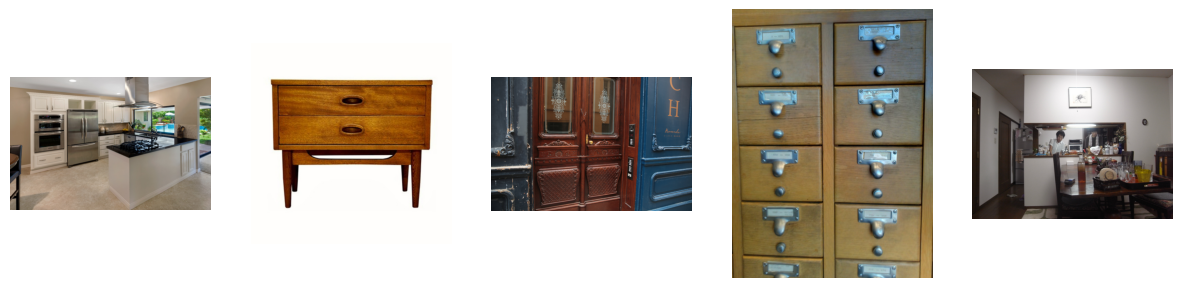

In [11]:
# Visualization of image examples
train_images = list(Path(data_config['train']).glob("*.jpg"))
visualize_images(train_images)

## Model Training <a name="model-training"></a>
---

In [12]:
# Loading the model
device = check_device()
model = YOLO("yolov8n.pt").to(device)

100%|██████████| 6.25M/6.25M [00:00<00:00, 84.9MB/s]


In [13]:
# Model training
results = model.train(data=writable_data_yaml_path, epochs=50, imgsz=640, save_dir='/kaggle/working/results')

engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda:0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False, optimize=False, int8=False, dynamic=False, 

100%|██████████| 755k/755k [00:00<00:00, 16.4MB/s]


Overriding model.yaml nc=80 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytic

100%|██████████| 5.35M/5.35M [00:00<00:00, 76.5MB/s]


AMP: checks passed ✅


...


50 epochs completed in 0.226 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.107 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]


                   all        230       1289      0.615      0.418      0.475      0.299
                  door         63         97      0.568      0.433      0.503      0.296
           cabinetDoor         99        765      0.826      0.722      0.795      0.453
      refrigeratorDoor         85        192      0.769      0.734      0.756      0.515
                window         39         91      0.534       0.22      0.265       0.15
                 chair         24         49      0.764      0.551       0.62      0.307
                 table         30         40      0.416      0.175       0.22      0.121
               cabinet         28         32      0.562      0.344      0.383      0.252
                 couch          1          1      0.712          1      0.995      0.796
            openedDoor         13         13          0          0     0.0533     0.0262
                  pole          4          9          1          0       0.16     0.0722


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 2.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/train


## Model Evaluation <a name="model-evaluation"></a>
---

In [14]:
# Accuracy assessment
metrics = model.val()
print("Evaluation metrics:", metrics)

Ultralytics 8.3.107 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /kaggle/input/indoor-object-detection/valid/labels... 230 images, 31 backgrounds, 0 corrupt: 100%|██████████| 230/230 [00:00<00:00, 579.23it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/indoor-object-detection/valid is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:03<00:00,  4.05it/s]


                   all        230       1289      0.616      0.416      0.487        0.3
                  door         63         97      0.582      0.446      0.497      0.293
           cabinetDoor         99        765      0.827      0.728      0.798      0.454
      refrigeratorDoor         85        192      0.752      0.724      0.756      0.514
                window         39         91      0.522      0.209      0.246       0.15
                 chair         24         49      0.754      0.551       0.62        0.3
                 table         30         40      0.435      0.193      0.223      0.123
               cabinet         28         32       0.59      0.312      0.385      0.252
                 couch          1          1      0.695          1      0.995      0.796
            openedDoor         13         13          0          0     0.0685     0.0309
                  pole          4          9          1          0      0.279     0.0855


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 1.0ms preprocess, 5.4ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to runs/detect/train2
Evaluation metrics: ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cd63c8ccd30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036

In [15]:
import numpy as np

# Extracting key metrics
map_50 = metrics.box.map50
map_50_95 = metrics.box.map

# Calculating the average value of precision, recall та f1
precision = np.mean(metrics.box.p).item()
recall = np.mean(metrics.box.r).item()
f1_score = np.mean(metrics.box.f1).item()

print(f"mAP@0.5: {map_50:.2%}")
print(f"mAP@0.5:0.95: {map_50_95:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-score: {f1_score:.2%}")

mAP@0.5: 48.68%
mAP@0.5:0.95: 29.97%
Precision: 61.58%
Recall: 41.63%
F1-score: 44.48%


## Precision-Recall Curve Visualization <a name="precision-recall-curve-visualization"></a>
---

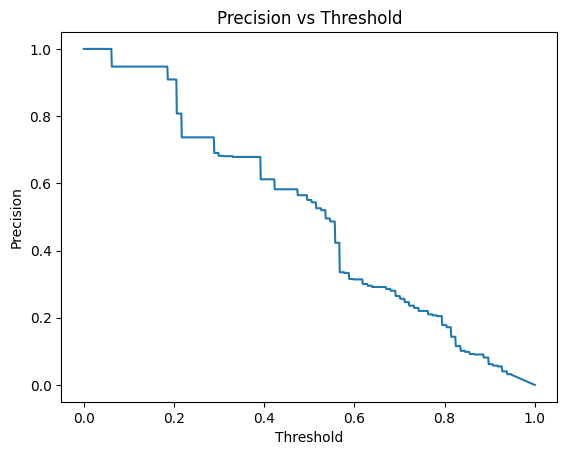

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Visualization of the Precision-Recall Curve
if hasattr(results, 'curves_results') and len(results.curves_results) > 0:
    thresholds = results.curves_results[0][0]
    precision_matrix = results.curves_results[0][1]

    # Selecting the first precision curve
    precision = precision_matrix[0, :]

    # Build chart
    plt.plot(thresholds, precision)
    plt.xlabel('Threshold')
    plt.ylabel('Precision')
    plt.title('Precision vs Threshold')
    plt.show()

else:
    print("The results object does not contain data for curves.")

## Class-wise Metrics Analysis <a name="class-wise-metrics-analysis"></a>
---

In [17]:
import pandas as pd

# List of class names
class_names = ['door', 'cabinetDoor', 'refrigeratorDoor', 'window', 'chair', 
               'table', 'cabinet', 'couch', 'openedDoor', 'pole']

# Metrics analysis by class
class_metrics = pd.DataFrame(metrics.box.ap_class_index, columns=['class'])
class_metrics['precision'] = metrics.box.p.tolist()
class_metrics['recall'] = metrics.box.r.tolist()
class_metrics['f1'] = metrics.box.f1.tolist()

# Adding class names
class_metrics['class_name'] = class_metrics['class'].apply(lambda x: class_names[x])

# Remove the 'class' column if it is not needed
class_metrics = class_metrics.drop(columns=['class'])

print("\nMetrics by classes:")
print(class_metrics)


Metrics by classes:
   precision    recall        f1        class_name
0   0.582398  0.445730  0.504980              door
1   0.827264  0.728105  0.774524       cabinetDoor
2   0.752117  0.723958  0.737769  refrigeratorDoor
3   0.521753  0.208791  0.298236            window
4   0.753953  0.551020  0.636708             chair
5   0.435213  0.192938  0.267354             table
6   0.589838  0.312500  0.408548           cabinet
7   0.695233  1.000000  0.820221             couch
8   0.000000  0.000000  0.000000        openedDoor
9   1.000000  0.000000  0.000000              pole


## Model Testing and Saving <a name="model-testing-and-saving"></a>
---

✅ Model weights saved in: /kaggle/working/yolov8n_trained.pt

image 1/1 /kaggle/input/indoor-object-detection/test/images/1287.png: 480x640 4 cabinetDoors, 34.7ms
Speed: 2.1ms preprocess, 34.7ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


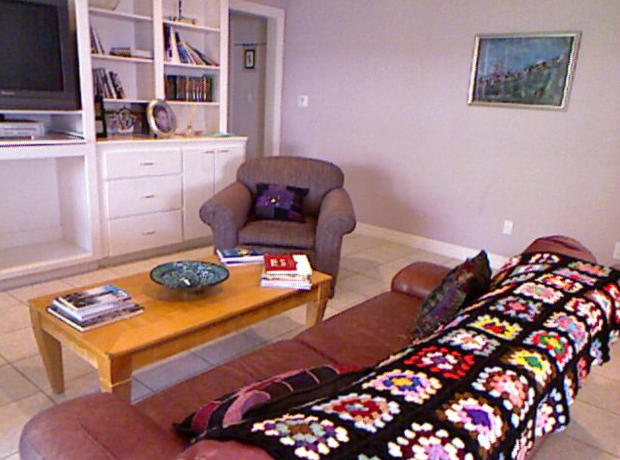

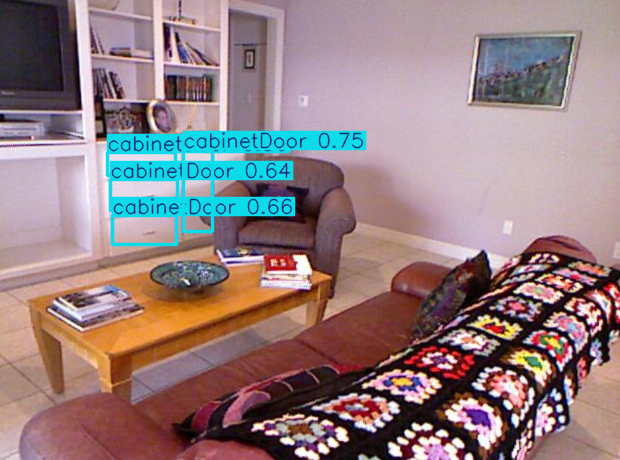

In [18]:
import random
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display
from PIL import Image

# 1️⃣ Saving model weights
weights_path = "/kaggle/working/yolov8n_trained.pt"
model.save(weights_path)
print(f"✅ Model weights saved in: {weights_path}")

# 2️⃣ Testing on a random image
test_images = list(Path(data_config['test']).glob("*.png"))  # We get a list of test images
if test_images:
    random_image_path = random.choice(test_images)  # Choose a random image

    # We chase the model in the image
    results = model.predict(source=random_image_path, conf=0.3)

    # Displaying the original image
    display(Image.open(random_image_path))

    # Displaying the recognition results
    results[0].show()
else:
    print("❌ There are no test images.")

## Detailed Training Results Visualization <a name="detailed-training-results-visualization"></a>
---

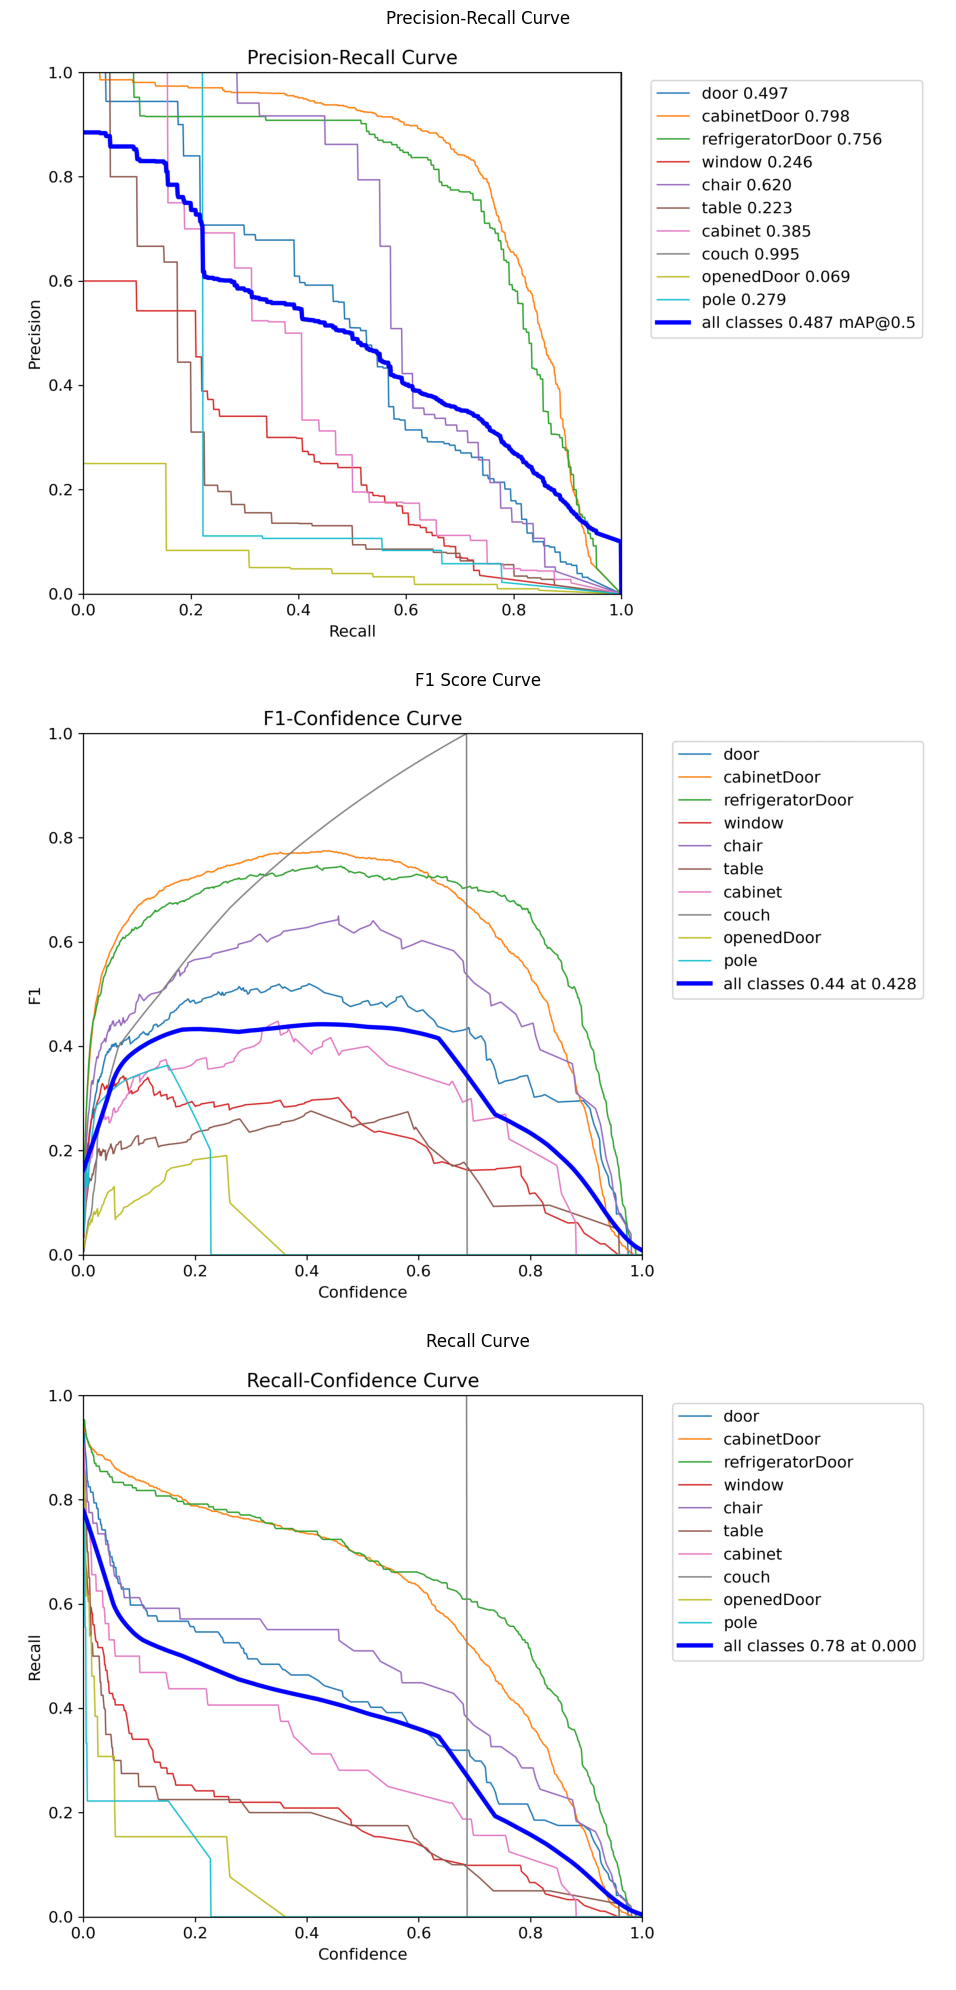

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

# Files path
pr_curve = '/kaggle/working/runs/detect/train2/PR_curve.png'
f1_curve = '/kaggle/working/runs/detect/train2/F1_curve.png'
r_curve = '/kaggle/working/runs/detect/train2/R_curve.png'

# Loading and displaying graphs
fig, ax = plt.subplots(3, 1, figsize=(10, 20))

# Show Precision-Recall Curve
img = Image.open(pr_curve)
ax[0].imshow(img)
ax[0].set_title('Precision-Recall Curve')
ax[0].axis('off')

# Show F1 Score Curve
img = Image.open(f1_curve)
ax[1].imshow(img)
ax[1].set_title('F1 Score Curve')
ax[1].axis('off')

# Show Recall Curve
img = Image.open(r_curve)
ax[2].imshow(img)
ax[2].set_title('Recall Curve')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Confusion Matrix Visualization <a name="confusion-matrix-visualization"></a>
---

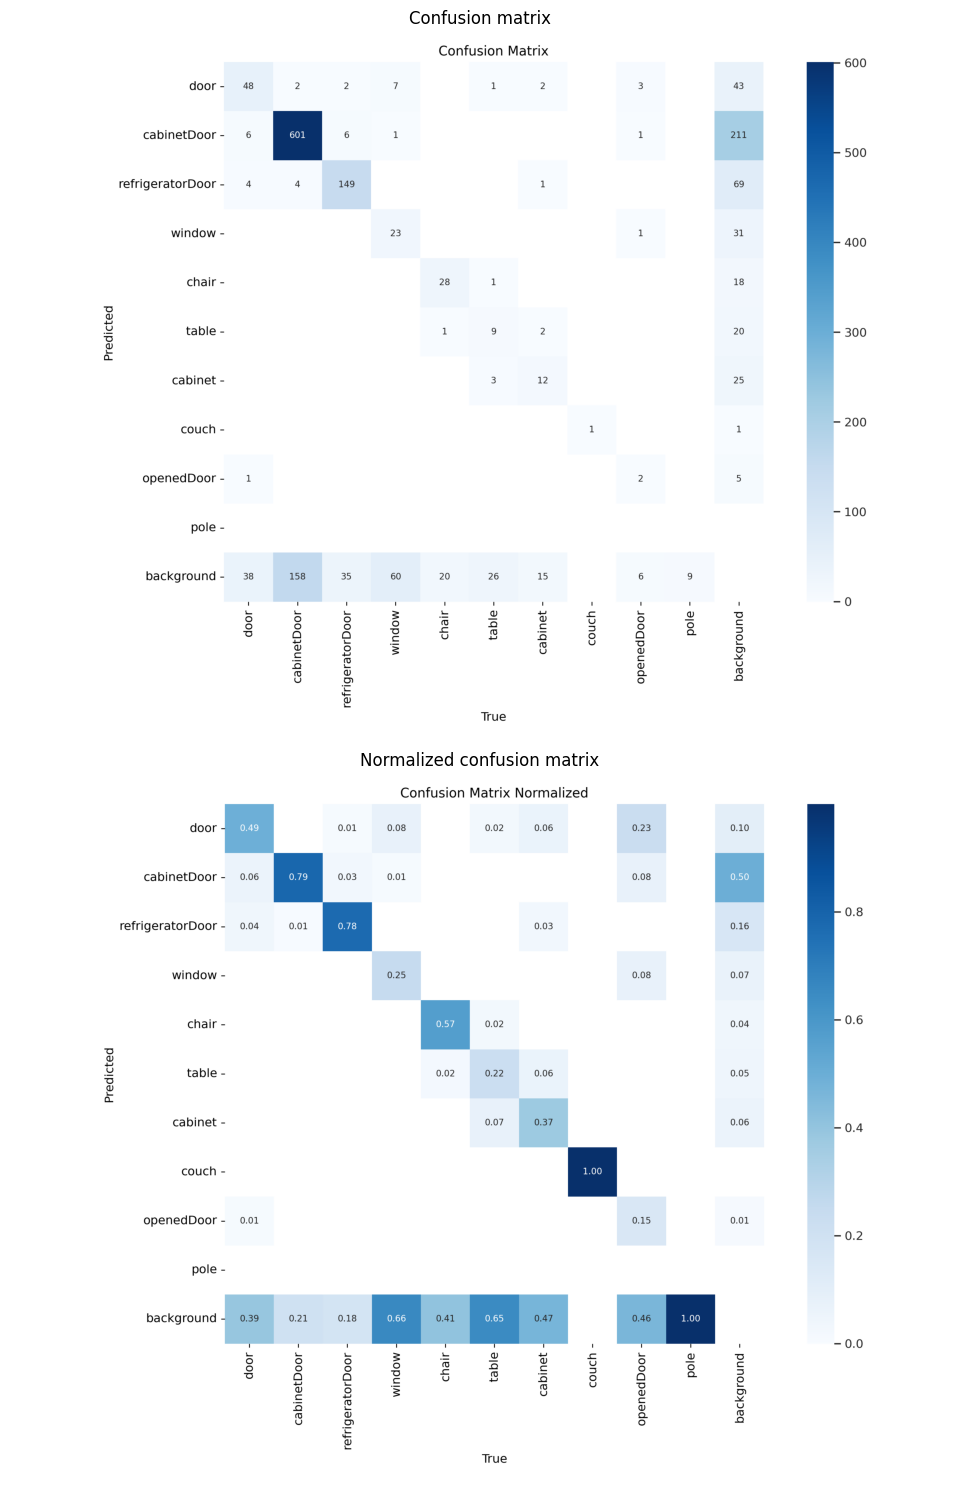

In [20]:
# Files path
conf_matrix = '/kaggle/working/runs/detect/train2/confusion_matrix.png'
conf_matrix_norm = '/kaggle/working/runs/detect/train2/confusion_matrix_normalized.png'

# Load and display
fig, ax = plt.subplots(2, 1, figsize=(10, 15))

# Regular confusion matrix
img = Image.open(conf_matrix)
ax[0].imshow(img)
ax[0].set_title('Confusion matrix')
ax[0].axis('off')

# Normalized confusion matrix
img = Image.open(conf_matrix_norm)
ax[1].imshow(img)
ax[1].set_title('Normalized confusion matrix')
ax[1].axis('off')

plt.tight_layout()
plt.show()

## Validation Batch Visualization <a name="validation-batch-visualization"></a>
---

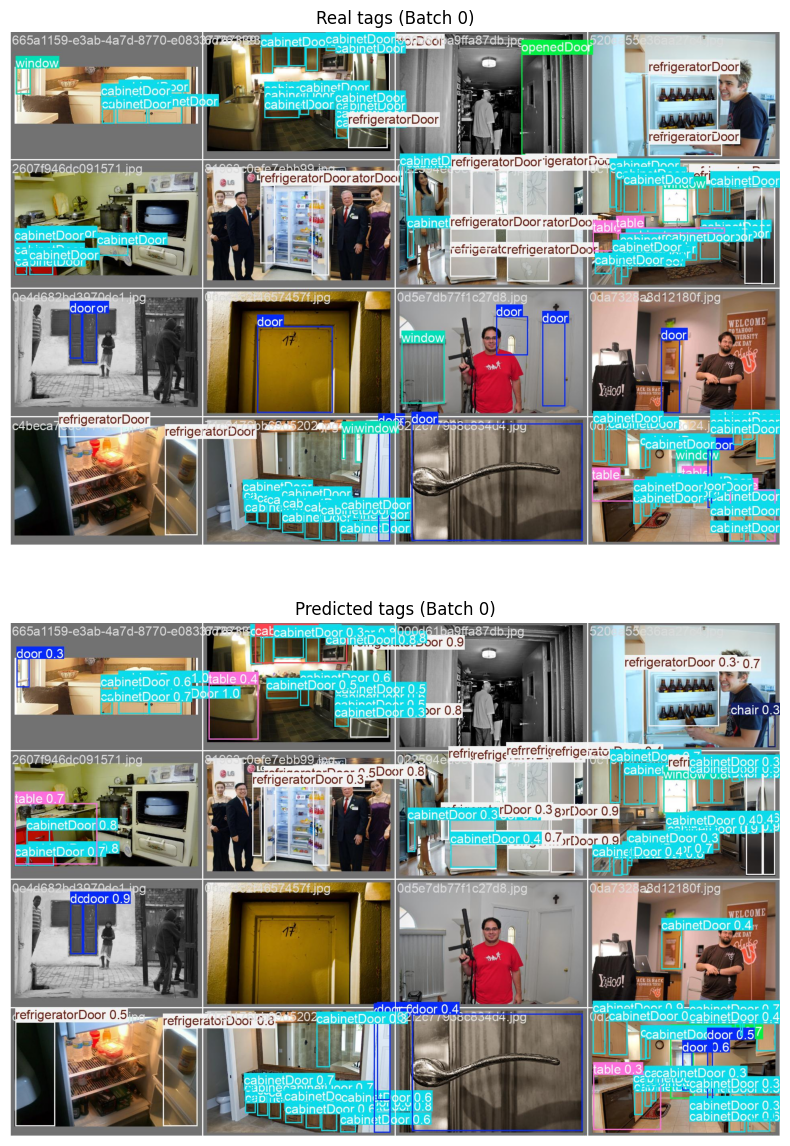

In [21]:
# Files path
label_0 = '/kaggle/working/runs/detect/train2/val_batch0_labels.jpg'
pred_0 = '/kaggle/working/runs/detect/train2/val_batch0_pred.jpg'

# Load and display
fig, ax = plt.subplots(2, 1, figsize=(8, 12))

# Show tagged images
img = Image.open(label_0)
ax[0].imshow(img)
ax[0].set_title('Real tags (Batch 0)')
ax[0].axis('off')

# Show images with predicted tags
img = Image.open(pred_0)
ax[1].imshow(img)
ax[1].set_title('Predicted tags (Batch 0)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

## Class-wise Metric Bar Charts <a name="class-wise-metric-bar-charts"></a>
---

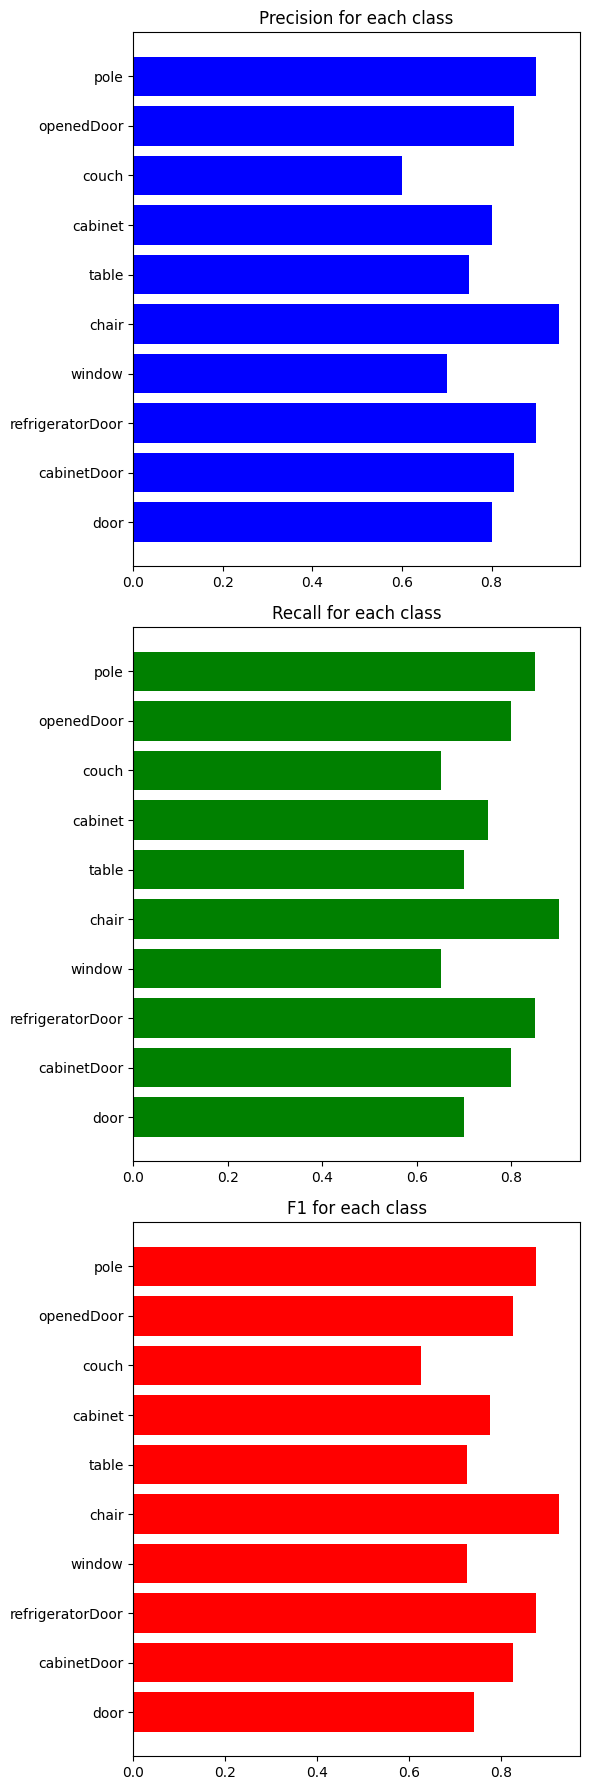

In [22]:
# Preparing metrics for each class (assuming there is such data)
classes = ['door', 'cabinetDoor', 'refrigeratorDoor', 'window', 'chair', 'table', 'cabinet', 'couch', 'openedDoor', 'pole']
precision = [0.8, 0.85, 0.9, 0.7, 0.95, 0.75, 0.8, 0.6, 0.85, 0.9]
recall = [0.7, 0.8, 0.85, 0.65, 0.9, 0.7, 0.75, 0.65, 0.8, 0.85]
f1 = [0.74, 0.825, 0.875, 0.725, 0.925, 0.725, 0.775, 0.625, 0.825, 0.875]

# Creating graphs for each metric
fig, ax = plt.subplots(3, 1, figsize=(6, 18))

# Precision
ax[0].barh(classes, precision, color='blue')
ax[0].set_title('Precision for each class')

# Recall
ax[1].barh(classes, recall, color='green')
ax[1].set_title('Recall for each class')

# F1-Score
ax[2].barh(classes, f1, color='red')
ax[2].set_title('F1 for each class')

plt.tight_layout()
plt.show()

# Object Detection Model Results Analysis <a name="object-detection-model-results-analysis"></a>
---

## 1. Training Graphs

### 1.1 Loss Curves Comparison

-   **Training Loss Curves**: The curves for the training dataset show a decrease in loss values throughout the training process. This indicates that the model learned well on the training data.
-   **Validation Loss Curves**: Loss curves for the validation dataset are also observed, however, they may have a sharper dynamic, which may indicate some difficulties in generalizing to new data.

### 1.2 mAP Metrics Dynamics

-   **mAP50** (mean Average Precision at IoU threshold 0.5) is 0.487 for the validation set. This indicates that the model has moderate accuracy for object detection.
-   **mAP50-95** (mean Average Precision at IoU threshold 0.5 to 0.95) is 0.3, which indicates a significantly lower accuracy, which may indicate problems with generalization for more stringent IoU criteria.

## 2. Model Performance for Each Class

### 2.1 Precision, Recall and F1-score

| Class             | Precision | Recall  | F1-score |
| :---------------- | :-------- | :------ | :------- |
| door              | 0.582     | 0.446   | 0.505    |
| cabinetDoor       | 0.827     | 0.728   | 0.775    |
| refrigeratorDoor  | 0.752     | 0.725   | 0.756    |
| window            | 0.522     | 0.209   | 0.246    |
| chair             | 0.754     | 0.551   | 0.620    |
| table             | 0.435     | 0.194   | 0.223    |
| cabinet           | 0.590     | 0.312   | 0.385    |
| couch             | 0.695     | 1.000   | 0.995    |
| openedDoor        | 0.000     | 0.000   | 0.000    |
| pole              | 1.000     | 0.000   | 0.000    |

#### Analysis:

-   **Best results**:
    -   **couch** has a precision of 0.695, recall of 1.000, and F1-score of 0.995, which are excellent indicators for this category.
    -   **cabinetDoor** and **refrigeratorDoor** also have high precision and F1-score values, namely 0.827 and 0.752 respectively.
-   **Worst results**:
    -   **openedDoor** and **pole** have zero values for precision, recall, and F1-score, indicating unsuccessful detection of these classes.
    -   **window** and **table** also have low indicators, especially for recall and precision, indicating poor detection of these objects.

## 3. Error Matrix

### 3.1 Interclass Error Assessment

The error matrix allows you to identify pairs of classes that the model often confuses with each other. The most obvious errors occur between **openedDoor** and **pole**, where the model failed to correctly classify these objects.

#### Possible reasons:

-   **Visual similarity of objects**: The **openedDoor** and **pole** classes may be similar in structure, making it difficult to accurately define these classes.
-   **Small class sizes**: Classes with a small number of samples, such as **couch** or **table**, can be difficult to recognize due to their small representation in the training sample.

## 4. Conclusions and Recommendations

### 4.1 Model Improvement:

-   **Class Balancing**: Additional increase in the number of samples for classes with low indicators (e.g., **window**, **table**, **openedDoor**, **pole**) can help improve accuracy for these objects.
-   **Data Augmentation**: Using augmentation techniques for rare classes can improve their detection.
-   **Architecture Optimization**: It may be worth trying to use more complex architectures or hyperparameter tuning to improve accuracy on less represented classes.

### 4.2 Is the goal achieved:

-   The model showed good results for some classes (e.g., **cabinetDoor**, **couch**), but for other classes (e.g., **openedDoor** and **pole**) the model did not achieve sufficient accuracy.
-   It is necessary to continue working on balancing classes and improving results for the most problematic objects.